In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt #为了画图
%matplotlib inline

In [2]:
words=open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
block_size=3 #上下文长度，也就是模型一次能看到几个字符
# 建立数据集
def build_dataset(words):
    
    
    X,Y=[],[]
    for w in words: #只用前1000个单词来训练
        #print(w)
        context=[0]*block_size #用0来表示context的开始
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context=context[1:]+[ix] #把context向右移动，加入新的字符


    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words) #打乱数据集
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])
    

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
#MLP
n_emb=10
n_hidden=200

g=torch.Generator().manual_seed(2147483647)
C=torch.rand(vocab_size,n_emb)
W1=torch.rand((n_emb*block_size,n_hidden),      generator=g) * 0.2
b1=torch.rand(n_hidden,                       generator=g) * 0.01
W2=torch.rand((n_hidden,vocab_size),           generator=g)*0.01
b2=torch.rand(vocab_size,                       generator=g)*0
parameters = [C,W1,b1,W2,b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


# 参数初始化部分的选择
在初始化后，我们希望预测对任何一个字符都是相同的
logits=h @ W2 + b2 #线性变换，得到32,27
对上面这个式子进行softmax,也就是转化成概率，我们希望每个字符出现的概率是相同的，但是由于都是随机初始的，所以会导致有些数特别小，有些数特别大，这样计算损失函数就会很大，不利于后面训练。
## 解决办法
把b2初始化为零，把w2的初始化*0.01
## 第二个问题
由于h=torch.tanh(hpreact) 
tanh函数只有在越接近零的位置，他的梯度才会明显，如果hpreact很大或者很小，那么h的梯度就会很小，所以我们希望hpreact不要太大或者太小，我们希望他在0附近
### 解决方法
把w1,和b1的初始化*0.01,这样


In [9]:
C.shape

torch.Size([27, 10])

In [10]:
## 完整流程
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    #在训练集里随机选取minibatch
    ix = torch.randint(0, Xtr.shape[0],(batch_size,) ,generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    #前向传播
    emb = C[Xb]# 编码，Xb是32,3，C是27,10，最后编码结果是32,3,10
    embcat=emb.view(emb.shape[0],-1) #把每个样本的3,10的编码结果拼成一个30维的向量，得到32,30
    hpreact=embcat @ W1 + b1 #线性变换，得到32,200
    h=torch.tanh(hpreact) #非线性变换，得到32,
    logits=h @ W2 + b2 #线性变换，得到32,27
    loss=F.cross_entropy(logits, Yb) #计算loss，标量

    #反向传播
    for p in parameters:
        p.grad = None
    loss.backward()


    #更新参数
    lr=0.1 if i<100000 else 0.01
    for p in parameters:
        p.data +=  -lr* p.grad


    #track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/200000: 3.2950
  10000/200000: 2.2866
  20000/200000: 2.3668
  30000/200000: 2.4668
  40000/200000: 2.1690
  50000/200000: 2.0262
  60000/200000: 1.8699
  70000/200000: 1.9600
  80000/200000: 1.6691
  90000/200000: 1.9106
 100000/200000: 2.4577
 110000/200000: 1.9960
 120000/200000: 2.6414
 130000/200000: 2.2482
 140000/200000: 1.9939
 150000/200000: 1.9513
 160000/200000: 1.9895
 170000/200000: 2.1566
 180000/200000: 1.8636
 190000/200000: 1.9890


In [11]:
# logits=torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.rand(4)*10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
print(logits)
print(probs)
print(loss)

tensor([8.9177, 5.3717, 7.1701, 9.4441])
tensor([0.3453, 0.0100, 0.0602, 0.5846])
tensor(2.8109)


In [12]:
-torch.tensor(1.0/27.0).log()

tensor(3.2958)

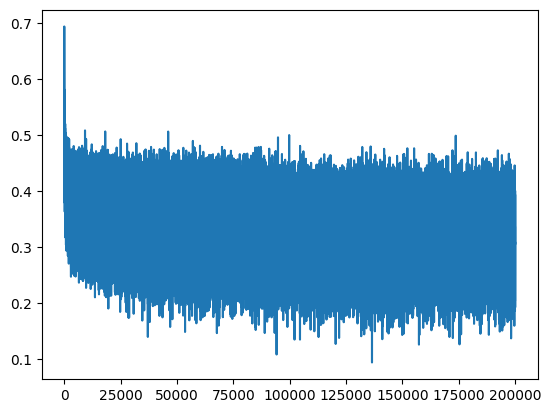

In [13]:
plt.plot(lossi)

In [14]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr,Ytr),
        'val': (Xdev,Ydev),
        'test': (Xte,Yte) 
    }[split]
    emb = C[x] #N,block_size,n_emb
    embcat=emb.view(emb.shape[0],-1) #N,block_size*n_emb
    h = torch.tanh(embcat @ W1 + b1) #N,n_hidden
    logits=h @ W2 + b2 #N,vocab_size
    loss=F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')


split_loss('train')
split_loss('val')

train loss: 2.0942
val loss: 2.1306


In [15]:
# 调用模型
g=torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])] #1,block_size,n_emb
        embcat=emb.view(emb.shape[0],-1) #1,block_size*n_emb
        h = torch.tanh(embcat @ W1 + b1) #1,n_hidden
        logits=h @ W2 + b2 #1,vocab_size
        probs = F.softmax(logits, dim=1) #1,vocab_size
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() #从概率分布中采样一个字符的索引
        out.append(itos[ix]) #把索引转换成字符，加入输出列表
        context=context[1:]+[ix] #更新context，向右移动，加入新的字符
        if ix == 0: #如果采样到结束符，就停止生成
            break
    print(''.join(out))

mora.
mayah.
see.
madhayla.
reisha.
endra.
gradered.
elin.
shi.
jenleigh.
estanar.
kayzioh.
kamin.
shurvighaimies.
kin.
reelynn.
novana.
ubreyven.
jamelizeka.
kaysh.


In [ ]:
##下面是新的
## 完整流程
max_steps = 2000
batch_size = 32
lossi = []
for i in range(max_steps):
    #在训练集里随机选取minibatch
    ix = torch.randint(0, Xtr.shape[0],(batch_size,) ,generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    #前向传播
    emb = C[Xb]# 编码，Xb是32,3，C是27,10，最后编码结果是32,3,10
    embcat=emb.view(emb.shape[0],-1) #把每个样本的3,10的编码结果拼成一个30维的向量，得到32,30
    hpreact=embcat @ W1 + b1 #线性变换，得到32,200
    hpreact = (hpreact - hpreact.mean(dim=0, keepdim=True)) / hpreact.std(dim=0, keepdim=True)   #批量归一化
    h=torch.tanh(hpreact) #非线性变换，得到32,
    logits=h @ W2 + b2 #线性变换，得到32,27
    loss=F.cross_entropy(logits, Yb) #计算loss，标量

    #反向传播
    for p in parameters:
        p.grad = None
    loss.backward()


    #更新参数
    lr=0.1 if i<100000 else 0.01
    for p in parameters:
        p.data +=  -lr* p.grad


    #track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
